# SciFact Retrieval Baselines

Ноутбук сравнивает три retrieval-пайплайна на `BEIR SciFact`:

1. `BM25 / keyword baseline`;
2. `semantic search` по embedding-модели;
3. `semantic search + graph rerank` по сущностям и связям между ними.

Обучаемая модель в этом ноутбуке не строится. Здесь фиксируется базовый уровень качества для дальнейших экспериментов.

Зависимости для запуска в notebook kernel:

```python
%pip install pandas matplotlib numpy sentence-transformers langchain-text-splitters
```


## Подготовка окружения


In [1]:
from __future__ import annotations

import json
import math
import re
import sys
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "notebooks":
    NOTEBOOK_DIR = Path.cwd() / "notebooks"

PROJECT_ROOT = NOTEBOOK_DIR.parent
PACKAGES_DIR = PROJECT_ROOT / "src" / "packages"
DATA_DIR = NOTEBOOK_DIR / "data"
DATASET_DIR = DATA_DIR / "scifact"
MODEL_CACHE_DIR = DATA_DIR / "hf_cache"

if str(PACKAGES_DIR) not in sys.path:
    sys.path.insert(0, str(PACKAGES_DIR))

from sciguide_pipeline import SourceDocument
from sciguide_pipeline.infrastructure.processing import (
    DeterministicEntityExtractor,
    LangChainTextChunker,
)


## Настройки эксперимента


In [2]:
MAX_DOCUMENTS = 1200
MAX_QUERIES = 100
CHUNK_SIZE = 900
CHUNK_OVERLAP = 120
EMBEDDING_MODEL_NAME = "BAAI/bge-m3"
K_VALUES = [5, 10]

BM25_TOP_CHUNKS = 40
SEMANTIC_TOP_CHUNKS = 40
GRAPH_VECTOR_WEIGHT = 0.75
GRAPH_SIGNAL_WEIGHT = 0.25


## Загрузка SciFact


In [3]:
def load_jsonl(path: Path) -> list[dict]:
    with path.open(encoding="utf-8") as file:
        return [json.loads(line) for line in file]


def load_qrels(path: Path) -> dict[str, dict[str, int]]:
    frame = pd.read_csv(path, sep="	").rename(
        columns={"query-id": "query_id", "corpus-id": "corpus_id", "score": "relevance"}
    )
    result: dict[str, dict[str, int]] = defaultdict(dict)
    for row in frame.itertuples(index=False):
        result[str(row.query_id)][str(row.corpus_id)] = int(row.relevance)
    return dict(result)


corpus_rows = load_jsonl(DATASET_DIR / "corpus.jsonl")
query_rows = load_jsonl(DATASET_DIR / "queries.jsonl")
corpus = {str(row["_id"]): row for row in corpus_rows}
queries = {str(row["_id"]): row["text"] for row in query_rows}
qrels = load_qrels(DATASET_DIR / "qrels" / "test.tsv")

len(corpus), len(queries), len(qrels)


(5183, 1109, 300)

## Выборка для оценки


In [4]:
selected_query_ids = list(qrels.keys())[:MAX_QUERIES]
selected_qrels = {query_id: qrels[query_id] for query_id in selected_query_ids}
selected_queries = {query_id: queries[query_id] for query_id in selected_query_ids}

relevant_doc_ids = {
    doc_id
    for doc_relevances in selected_qrels.values()
    for doc_id, relevance in doc_relevances.items()
    if relevance > 0
}
selected_doc_ids = sorted(relevant_doc_ids)
for doc_id in corpus:
    if len(selected_doc_ids) >= MAX_DOCUMENTS:
        break
    if doc_id not in relevant_doc_ids:
        selected_doc_ids.append(doc_id)

selected_corpus = {doc_id: corpus[doc_id] for doc_id in selected_doc_ids}

selection_summary = pd.DataFrame(
    {
        "metric": ["documents", "queries", "qrels_rows", "relevant_documents"],
        "value": [
            len(selected_corpus),
            len(selected_queries),
            sum(len(items) for items in selected_qrels.values()),
            len(relevant_doc_ids),
        ],
    }
)
selection_summary


,metric,value
0,documents,1200
1,queries,100
2,qrels_rows,116
3,relevant_documents,101


## Нарезка документов


In [5]:
def document_text(raw_document: dict) -> str:
    return "\n\n".join(
        part.strip()
        for part in [raw_document.get("title", ""), raw_document.get("text", "")]
        if part and part.strip()
    )


source_documents = [
    SourceDocument(
        content=document_text(raw_document),
        document_id=doc_id,
        source_name=f"scifact::{doc_id}",
        metadata={"title": raw_document.get("title", ""), "beir_doc_id": doc_id},
    )
    for doc_id, raw_document in selected_corpus.items()
]

chunker = LangChainTextChunker(chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP)
chunks = chunker.chunk_documents(source_documents)

chunk_frame = pd.DataFrame(
    [
        {
            "chunk_id": chunk.id,
            "document_id": chunk.document_id,
            "text": chunk.text,
            "title": chunk.metadata.get("title", ""),
            "words": len(chunk.text.split()),
        }
        for chunk in chunks
    ]
)

chunk_frame[["chunk_id", "document_id", "words", "title"]].head()


/Users/timur/Desktop/FU/KR2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,chunk_id,document_id,words,title
0,10165258:0,10165258,9,GATA-3 regulates hematopoietic stem cell maintenance and cell-cycle entry.
1,10165258:1,10165258,133,GATA-3 regulates hematopoietic stem cell maintenance and cell-cycle entry.
2,10165258:2,10165258,37,GATA-3 regulates hematopoietic stem cell maintenance and cell-cycle entry.
3,10536636:0,10536636,66,Prevalence and Causes of Blindness and Low Vision in Southern Sudan
4,10582939:0,10582939,15,Induction therapy with autologous mesenchymal stem cells in living-related kidney transplants: a randomized controll...


## Токенизация


In [6]:
_TOKEN_PATTERN = re.compile(r"[0-9a-zA-ZА-Яа-яЁё]+(?:-[0-9a-zA-ZА-Яа-яЁё]+)*")
_STOPWORDS = {
    "a", "an", "and", "are", "as", "at", "be", "by", "for", "from", "in", "is", "of", "on", "or", "that", "the", "to", "was", "were", "with",
}


def tokenize(text: str) -> list[str]:
    return [
        token.lower()
        for token in _TOKEN_PATTERN.findall(text)
        if token.lower() not in _STOPWORDS and len(token) > 1
    ]


chunk_tokens = [tokenize(text) for text in chunk_frame["text"]]
query_tokens = {query_id: tokenize(text) for query_id, text in selected_queries.items()}

pd.DataFrame(
    {
        "object": ["chunks", "mean_chunk_tokens", "queries", "mean_query_tokens"],
        "value": [
            len(chunk_tokens),
            round(np.mean([len(tokens) for tokens in chunk_tokens]), 2),
            len(query_tokens),
            round(np.mean([len(tokens) for tokens in query_tokens.values()]), 2),
        ],
    }
)


,object,value
0,chunks,3691.00
1,mean_chunk_tokens,54.42
2,queries,100.00
3,mean_query_tokens,8.98


## BM25 baseline


In [7]:
def build_bm25_index(tokenized_documents: list[list[str]], k1: float = 1.5, b: float = 0.75):
    document_count = len(tokenized_documents)
    document_lengths = np.array([len(tokens) for tokens in tokenized_documents], dtype=float)
    average_length = float(document_lengths.mean()) if document_count else 0.0
    document_frequencies = Counter()
    term_frequencies = []

    for tokens in tokenized_documents:
        frequencies = Counter(tokens)
        term_frequencies.append(frequencies)
        document_frequencies.update(frequencies.keys())

    idf = {
        term: math.log(1 + (document_count - frequency + 0.5) / (frequency + 0.5))
        for term, frequency in document_frequencies.items()
    }
    return term_frequencies, document_lengths, average_length, idf, k1, b


def bm25_scores(query_terms: list[str], index) -> np.ndarray:
    term_frequencies, document_lengths, average_length, idf, k1, b = index
    scores = np.zeros(len(term_frequencies), dtype=float)
    unique_query_terms = set(query_terms)

    for doc_index, frequencies in enumerate(term_frequencies):
        score = 0.0
        document_length = document_lengths[doc_index]
        normalizer = k1 * (1 - b + b * document_length / average_length)
        for term in unique_query_terms:
            frequency = frequencies.get(term, 0)
            if not frequency:
                continue
            score += idf.get(term, 0.0) * frequency * (k1 + 1) / (frequency + normalizer)
        scores[doc_index] = score

    return scores


bm25_index = build_bm25_index(chunk_tokens)


## Semantic search


In [8]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_NAME,
    cache_folder=str(MODEL_CACHE_DIR),
)
chunk_embeddings = embedding_model.encode(
    chunk_frame["text"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True,
)
chunk_embeddings = np.asarray(chunk_embeddings, dtype=np.float32)
chunk_embeddings.shape


Batches: 100%|██████████| 116/116 [02:12<00:00,  1.14s/it]


(3691, 1024)

## Графовые структуры


In [9]:
extractor = DeterministicEntityExtractor()
chunk_entities = [tuple(extractor.extract(text)) for text in chunk_frame["text"]]
entity_to_chunks: dict[str, set[int]] = defaultdict(set)
token_to_entities: dict[str, set[str]] = defaultdict(set)
entity_tokens: dict[str, set[str]] = {}
entity_edges = Counter()

for chunk_index, entities in enumerate(chunk_entities):
    unique_entities = list(dict.fromkeys(entities))
    for entity in unique_entities:
        entity_to_chunks[entity].add(chunk_index)
        tokens = set(extractor.extract_tokens(entity))
        entity_tokens[entity] = tokens
        for token in tokens:
            token_to_entities[token].add(entity)
    for index, left_entity in enumerate(unique_entities):
        for right_entity in unique_entities[index + 1 : index + 3]:
            entity_edges[(left_entity, right_entity)] += 1

neighbors: dict[str, set[str]] = defaultdict(set)
for left_entity, right_entity in entity_edges:
    neighbors[left_entity].add(right_entity)
    neighbors[right_entity].add(left_entity)

pd.DataFrame(
    {
        "metric": ["entities", "edges", "mean_entities_per_chunk"],
        "value": [
            len(entity_to_chunks),
            len(entity_edges),
            round(np.mean([len(entities) for entities in chunk_entities]), 2),
        ],
    }
)


,metric,value
0,entities,32962.00
1,edges,59797.00
2,mean_entities_per_chunk,9.73


## Скоринг и агрегация


In [10]:
def normalize_scores(scores: np.ndarray) -> np.ndarray:
    if scores.size == 0:
        return scores
    min_score = float(scores.min())
    max_score = float(scores.max())
    if max_score == min_score:
        return np.ones_like(scores) if max_score else np.zeros_like(scores)
    return (scores - min_score) / (max_score - min_score)


def aggregate_chunk_scores_to_documents(chunk_scores: np.ndarray, top_chunk_count: int) -> dict[str, float]:
    top_indices = np.argsort(chunk_scores)[::-1][:top_chunk_count]
    document_scores: dict[str, float] = {}
    for chunk_index in top_indices:
        score = float(chunk_scores[chunk_index])
        if score <= 0:
            continue
        doc_id = str(chunk_frame.iloc[chunk_index]["document_id"])
        document_scores[doc_id] = max(document_scores.get(doc_id, score), score)
    return document_scores


def graph_scores_for_query(query_text: str) -> np.ndarray:
    query_entities = set(extractor.extract(query_text))
    query_entity_tokens = set(extractor.extract_tokens(query_text))
    matched_entities = set(query_entities)
    for token in query_entity_tokens:
        matched_entities.update(token_to_entities.get(token, set()))

    expanded_entities = set(matched_entities)
    for entity in matched_entities:
        expanded_entities.update(neighbors.get(entity, set()))

    scores = np.zeros(len(chunk_entities), dtype=float)
    for chunk_index, entities in enumerate(chunk_entities):
        entity_set = set(entities)
        exact_hits = len(entity_set & matched_entities)
        neighbor_hits = len(entity_set & expanded_entities) - exact_hits
        scores[chunk_index] = exact_hits + 0.35 * max(neighbor_hits, 0)

    return scores


## Retrieval-пайплайны


In [11]:
def run_bm25_pipeline() -> dict[str, dict[str, float]]:
    results = {}
    for query_id, tokens in query_tokens.items():
        scores = bm25_scores(tokens, bm25_index)
        results[query_id] = aggregate_chunk_scores_to_documents(scores, BM25_TOP_CHUNKS)
    return results


def run_semantic_pipeline() -> dict[str, dict[str, float]]:
    query_texts = [selected_queries[query_id] for query_id in selected_queries]
    query_embeddings = embedding_model.encode(
        query_texts,
        normalize_embeddings=True,
        show_progress_bar=True,
    )
    query_embeddings = np.asarray(query_embeddings, dtype=np.float32)

    results = {}
    for query_index, query_id in enumerate(selected_queries):
        scores = chunk_embeddings @ query_embeddings[query_index]
        results[query_id] = aggregate_chunk_scores_to_documents(scores, SEMANTIC_TOP_CHUNKS)
    return results


def run_semantic_graph_pipeline() -> dict[str, dict[str, float]]:
    query_texts = [selected_queries[query_id] for query_id in selected_queries]
    query_embeddings = embedding_model.encode(
        query_texts,
        normalize_embeddings=True,
        show_progress_bar=True,
    )
    query_embeddings = np.asarray(query_embeddings, dtype=np.float32)

    results = {}
    for query_index, query_id in enumerate(selected_queries):
        vector_scores = normalize_scores(chunk_embeddings @ query_embeddings[query_index])
        structural_scores = normalize_scores(graph_scores_for_query(selected_queries[query_id]))
        scores = GRAPH_VECTOR_WEIGHT * vector_scores + GRAPH_SIGNAL_WEIGHT * structural_scores
        results[query_id] = aggregate_chunk_scores_to_documents(scores, SEMANTIC_TOP_CHUNKS)
    return results


## Метрики


In [12]:
def ranked_doc_ids(result_scores: dict[str, float]) -> list[str]:
    return [
        doc_id
        for doc_id, _ in sorted(result_scores.items(), key=lambda item: item[1], reverse=True)
    ]


def dcg(relevances: list[float]) -> float:
    return sum(
        ((2 ** relevance) - 1) / math.log2(index + 2)
        for index, relevance in enumerate(relevances)
    )


def evaluate_retrieval(qrels: dict[str, dict[str, int]], results: dict[str, dict[str, float]], k_values: list[int]) -> dict[str, float]:
    metrics = {f"ndcg@{k}": 0.0 for k in k_values}
    metrics.update({f"recall@{k}": 0.0 for k in k_values})
    metrics.update({f"precision@{k}": 0.0 for k in k_values})
    metrics.update({f"mrr@{k}": 0.0 for k in k_values})

    for query_id, relevant_docs in qrels.items():
        ranked_ids = ranked_doc_ids(results.get(query_id, {}))
        relevant_doc_ids = {doc_id for doc_id, relevance in relevant_docs.items() if relevance > 0}
        ideal_relevances = sorted(relevant_docs.values(), reverse=True)

        for k in k_values:
            top_k_ids = ranked_ids[:k]
            top_k_relevances = [relevant_docs.get(doc_id, 0) for doc_id in top_k_ids]
            hits = sum(doc_id in relevant_doc_ids for doc_id in top_k_ids)
            ideal_dcg = dcg(ideal_relevances[:k])

            metrics[f"ndcg@{k}"] += dcg(top_k_relevances) / ideal_dcg if ideal_dcg else 0.0
            metrics[f"recall@{k}"] += hits / len(relevant_doc_ids) if relevant_doc_ids else 0.0
            metrics[f"precision@{k}"] += hits / k
            metrics[f"mrr@{k}"] += next(
                (1.0 / rank for rank, doc_id in enumerate(top_k_ids, start=1) if doc_id in relevant_doc_ids),
                0.0,
            )

    query_count = len(qrels)
    return {name: round(value / query_count, 4) for name, value in metrics.items()}


## Сравнение результатов


In [13]:
bm25_results = run_bm25_pipeline()
semantic_results = run_semantic_pipeline()
semantic_graph_results = run_semantic_graph_pipeline()

metrics_frame = pd.DataFrame(
    [
        {"pipeline": "BM25 / keyword", **evaluate_retrieval(selected_qrels, bm25_results, K_VALUES)},
        {"pipeline": "Semantic search", **evaluate_retrieval(selected_qrels, semantic_results, K_VALUES)},
        {"pipeline": "Semantic + graph rerank", **evaluate_retrieval(selected_qrels, semantic_graph_results, K_VALUES)},
    ]
)
metrics_frame


Batches: 100%|██████████| 4/4 [00:00<00:00,  5.65it/s]


,pipeline,ndcg@5,ndcg@10,recall@5,recall@10,precision@5,precision@10,mrr@5,mrr@10
0,BM25 / keyword,0.7687,0.7755,0.8628,0.8773,0.186,0.097,0.7507,0.7523
1,Semantic search,0.7626,0.7811,0.8527,0.9030,0.196,0.105,0.7377,0.7435
2,Semantic + graph rerank,0.7784,0.7911,0.8622,0.8997,0.198,0.104,0.7578,0.7615


## Визуализация

Метрики показаны в отдельных панелях. По оси X отложено изменение относительно `BM25 / keyword` в процентных пунктах; рядом с точками подписаны абсолютные значения метрик.


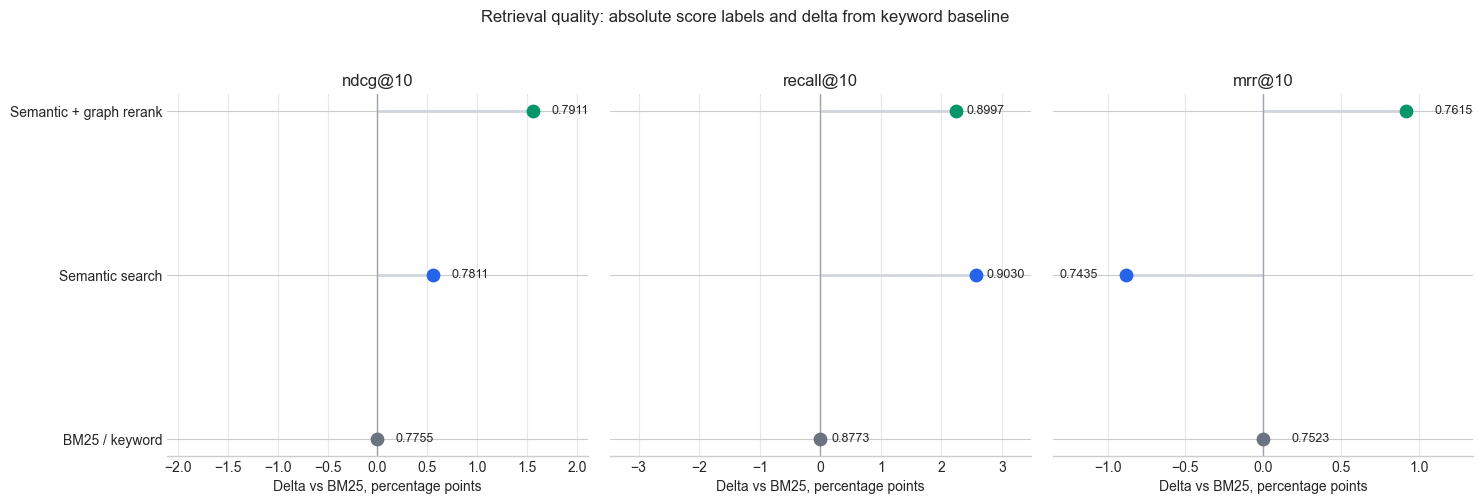

,pipeline,delta_ndcg@10_pp,delta_recall@10_pp,delta_mrr@10_pp
0,BM25 / keyword,0.00,0.00,0.00
1,Semantic search,0.56,2.57,-0.88
2,Semantic + graph rerank,1.56,2.24,0.92


In [16]:
metric_names = ["ndcg@10", "recall@10", "mrr@10"]
pipeline_order = ["BM25 / keyword", "Semantic search", "Semantic + graph rerank"]
baseline_name = "BM25 / keyword"

plot_data = metrics_frame.set_index("pipeline").loc[pipeline_order, metric_names]
delta_data = (plot_data - plot_data.loc[baseline_name]) * 100

colors = {
    "BM25 / keyword": "#6b7280",
    "Semantic search": "#2563eb",
    "Semantic + graph rerank": "#059669",
}

fig, axes = plt.subplots(1, len(metric_names), figsize=(15, 4.8), sharey=True)
y_positions = np.arange(len(pipeline_order))

for axis, metric_name in zip(axes, metric_names):
    values = delta_data[metric_name]
    axis.axvline(0, color="#9ca3af", linewidth=1)
    axis.hlines(
        y=y_positions,
        xmin=0,
        xmax=values.to_numpy(),
        color="#d1d5db",
        linewidth=2,
        zorder=1,
    )

    for y_position, pipeline_name in zip(y_positions, pipeline_order):
        delta_value = values.loc[pipeline_name]
        absolute_value = plot_data.loc[pipeline_name, metric_name]
        axis.scatter(
            delta_value,
            y_position,
            s=80,
            color=colors[pipeline_name],
            zorder=2,
        )
        label_offset = 0.18 if delta_value >= 0 else -0.18
        label_alignment = "left" if delta_value >= 0 else "right"
        axis.text(
            delta_value + label_offset,
            y_position,
            f"{absolute_value:.4f}",
            va="center",
            ha=label_alignment,
            fontsize=9,
        )

    max_abs_delta = max(1.0, float(np.nanmax(np.abs(values.to_numpy()))))
    axis.set_xlim(-max_abs_delta * 1.35, max_abs_delta * 1.35)
    axis.set_title(metric_name)
    axis.set_xlabel("Delta vs BM25, percentage points")
    axis.grid(axis="x", color="#e5e7eb", linewidth=0.8)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_visible(False)
    axis.tick_params(axis="y", length=0)

axes[0].set_yticks(y_positions)
axes[0].set_yticklabels(pipeline_order)
fig.suptitle("Retrieval quality: absolute score labels and delta from keyword baseline", y=1.04)
plt.tight_layout()
plt.show()

display(
    delta_data.reset_index()
    .rename(columns={metric: f"delta_{metric}_pp" for metric in metric_names})
    .round(2)
)


## Пример выдачи


In [15]:
sample_query_id = selected_query_ids[0]
sample_query = selected_queries[sample_query_id]

sample_rows = []
for pipeline_name, result in [
    ("BM25 / keyword", bm25_results),
    ("Semantic search", semantic_results),
    ("Semantic + graph rerank", semantic_graph_results),
]:
    for rank, doc_id in enumerate(ranked_doc_ids(result[sample_query_id])[:5], start=1):
        sample_rows.append(
            {
                "pipeline": pipeline_name,
                "rank": rank,
                "document_id": doc_id,
                "relevance": selected_qrels[sample_query_id].get(doc_id, 0),
                "title": selected_corpus[doc_id].get("title", ""),
            }
        )

print(sample_query)
display(pd.DataFrame(sample_rows))


0-dimensional biomaterials show inductive properties.


,pipeline,rank,document_id,relevance,title
0,BM25 / keyword,1,825728,0,Metastatic colonization requires the repression of the epithelial-mesenchymal transition inducer Prrx1.
1,BM25 / keyword,2,4465608,0,An atlas of active enhancers across human cell types and tissues
2,BM25 / keyword,3,4702639,0,An integrin β3–KRAS–RalB complex drives tumour stemness and resistance to EGFR inhibition
3,BM25 / keyword,4,1292369,0,Biochemical Properties of Highly Neuroinvasive Prion Strains
4,BM25 / keyword,5,2904102,0,Characterization of biochemical properties of Bacillus subtilis RecQ helicase.
5,Semantic search,1,4405194,0,Induction of human neuronal cells by defined transcription factors
6,Semantic search,2,72159,0,induction of early IFN-inducible genes in the absence of type
7,Semantic search,3,3727986,0,A mechanically active heterotypic E-cadherin/N-cadherin adhesion enables fibroblasts to drive cancer cell invasion
8,Semantic search,4,1834762,0,Amyloid-DNA Composites of Bacterial Biofilms Stimulate Autoimmunity.
9,Semantic search,5,2121272,0,Stresses at the cell-to-substrate interface during locomotion of fibroblasts
